# France  Electricity Demand Forecasting - ML Pipeline

Exploratory data analysis for France electricity demand and generation data.

In [83]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
import warnings
import joblib
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

dir = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/fr")
WEATHER_PATH = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/weather-data/france_paris_2016-02-21_2026-02-21_hourly.csv")
OUTPUT_DIR = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fr")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

### Load Demand Data

In [84]:
DATE_RE = re.compile(r"^Journ[ée]e du (\d{2}/\d{2}/\d{4})\s*$", re.IGNORECASE)

def read_multi_day_rte_text_xls(path: Path) -> pd.DataFrame:
    raw = path.read_text(encoding="cp1252", errors="replace")
    lines = [ln.rstrip("\n") for ln in raw.splitlines()]

    blocks = []
    current_date = None
    current_block_lines = []

    def flush_block():
        nonlocal current_block_lines, current_date
        if current_date is None or not current_block_lines:
            current_block_lines = []
            return

        tsv = "\n".join(current_block_lines).strip()
        if not tsv:
            current_block_lines = []
            return

        df = pd.read_csv(
            StringIO(tsv),
            sep="\t",
            engine="python",
        )

        df = df.dropna(axis=1, how="all")

        if "Heures" in df.columns:
            heures = df["Heures"].astype(str).str.strip()
            df = df[heures.str.match(r"^\d{2}:\d{2}$")].copy()

        df["date"] = pd.to_datetime(current_date, format="%d/%m/%Y")
        blocks.append(df)

        current_block_lines = []

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        m = DATE_RE.match(line)

        if m:
            flush_block()
            current_date = m.group(1)

            i += 1
            while i < len(lines) and not lines[i].strip():
                i += 1

            if i < len(lines) and lines[i].strip().startswith("Heures"):
                current_block_lines.append(lines[i])
            else:
                pass
        else:
            if current_date is not None and line:
                current_block_lines.append(lines[i])
        i += 1

    flush_block()

    if not blocks:
        raise ValueError(f"No day blocks parsed from {path.name}")

    out = pd.concat(blocks, ignore_index=True)
    return out

demand_folder = os.path.join(dir, "demand")

dfs = []
for f in Path(demand_folder).glob("*.xls"):
    print("Reading:", f.name)
    df = read_multi_day_rte_text_xls(f)
    df["source_file"] = f.name
    dfs.append(df)

demand_df = pd.concat(dfs, ignore_index=True)

for c in demand_df.columns:
    if c not in ("Heures", "date", "source_file"):
        demand_df[c] = pd.to_numeric(demand_df[c], errors="coerce")

demand_df["datetime"] = pd.to_datetime(
    demand_df["date"].dt.strftime("%Y-%m-%d") + " " + demand_df["Heures"].str.strip().str.split(r"\s*-\s*").str[0],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

print("Demand loaded:", demand_df.shape)

Reading: conso_mix_RTE_2017.xls
Reading: conso_mix_RTE_2016.xls
Reading: conso_mix_RTE_2021.xls
Reading: conso_mix_RTE_2020.xls
Reading: conso_mix_RTE_2022.xls
Reading: conso_mix_RTE_2023.xls
Reading: conso_mix_RTE_2026.xls
Reading: conso_mix_RTE_2024.xls
Reading: conso_mix_RTE_2018.xls
Reading: conso_mix_RTE_2019.xls
Reading: conso_mix_RTE_2025.xls
Demand loaded: (355872, 7)


### Load Generation Data

In [85]:
DATE_RE = re.compile(r"^Donn[ée]es de r[ée]alisation du (\d{2}/\d{2}/\d{4})\s*$", re.IGNORECASE)
def read_multi_day_realisation_file(path: Path) -> pd.DataFrame:
    raw = path.read_text(encoding="cp1252", errors="replace")
    lines = [ln.rstrip("\n") for ln in raw.splitlines()]

    blocks = []
    current_date = None
    current_block_lines = []

    def flush_block():
        nonlocal current_block_lines, current_date
        if current_date is None or not current_block_lines:
            current_block_lines = []
            return

        tsv = "\n".join(current_block_lines).strip()
        if not tsv:
            current_block_lines = []
            return

        df = pd.read_csv(StringIO(tsv), sep="\t", engine="python")
        df = df.dropna(axis=1, how="all")

        if "Heures" in df.columns:
            heures = df["Heures"].astype(str).str.strip()
            mask = heures.str.match(r"^\d{2}:\d{2}\s*-\s*\d{2}:\d{2}$")
            df = df[mask].copy()

        df["date"] = pd.to_datetime(current_date, format="%d/%m/%Y")
        blocks.append(df)

        current_block_lines = []

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        m = DATE_RE.match(line)

        if m:
            flush_block()
            current_date = m.group(1)

            i += 1
            while i < len(lines) and not lines[i].strip():
                i += 1

            if i < len(lines) and lines[i].strip().startswith("Heures"):
                current_block_lines.append(lines[i])
        else:
            if current_date is not None and line:
                current_block_lines.append(lines[i])
        i += 1

    flush_block()

    if not blocks:
        raise ValueError(f"No 'Données de realisation' blocks parsed from {path.name}")

    return pd.concat(blocks, ignore_index=True)


generation_folder = os.path.join(dir, "generation")
dfs = []
for f in Path(generation_folder).glob("*.xls"):
    print("Reading:", f.name)
    df = read_multi_day_realisation_file(f)
    df["source_file"] = f.name
    dfs.append(df)

generation_df = pd.concat(dfs, ignore_index=True)

for c in generation_df.columns:
    if c not in ("Heures", "date", "source_file"):
        generation_df[c] = pd.to_numeric(generation_df[c], errors="coerce")

generation_df["datetime"] = pd.to_datetime(
    generation_df["date"].dt.strftime("%Y-%m-%d") + " " + generation_df["Heures"].str.strip().str.split(r"\s*-\s*").str[0],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

print("Generation loaded:", generation_df.shape)

Reading: RealisationDonneesProduction_2021.xls
Reading: RealisationDonneesProduction_2020.xls
Reading: RealisationDonneesProduction_2022.xls
Reading: RealisationDonneesProduction_2023.xls
Reading: RealisationDonneesProduction_2026.xls
Reading: RealisationDonneesProduction_2018.xls
Reading: RealisationDonneesProduction_2024.xls
Reading: RealisationDonneesProduction_2025.xls
Reading: RealisationDonneesProduction_2019.xls
Reading: RealisationDonneesProduction_2017.xls
Reading: RealisationDonneesProduction_2016.xls
Generation loaded: (88896, 17)


### Load Weather Data

In [86]:
weather_df = pd.read_csv(WEATHER_PATH)
weather_df = weather_df[weather_df['country_code'] == 'FR'].copy()
print("Weather loaded:", weather_df.shape)

Weather loaded: (87696, 14)


## 2. Data Preprocessing

In [87]:
demand_df = demand_df.set_index('datetime')
generation_df = generation_df.set_index('datetime')
demand_df.sort_index(inplace=True)
generation_df.sort_index(inplace=True)

In [88]:
print(f'Demand df: {demand_df.index[0]} to {demand_df.index[-1]}, {len(demand_df)} rows')
print(f'Generation df: {generation_df.index[0]} to {generation_df.index[-1]}, {len(generation_df)} rows')

Demand df: 2016-01-01 00:00:00 to 2026-02-23 23:45:00, 355872 rows
Generation df: 2016-01-01 00:00:00 to 2026-02-21 23:00:00, 88896 rows


In [89]:
demand_df = demand_df[demand_df.index.minute == 0]

In [90]:
generation_df.drop(columns=["Heures", "date", "source_file"], inplace=True)
demand_df.drop(columns=["Heures", "date", "source_file"], inplace=True)
demand_df = demand_df.add_suffix("_d")
generation_df = generation_df.add_suffix("_g")

In [91]:
df = demand_df.merge(generation_df, how="outer", left_index=True, right_index=True, suffixes=("_demand", "_generation"))
print(f"Merged shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Merged shape: (88968, 16)
Date range: 2016-01-01 00:00:00 to 2026-02-23 23:00:00


In [92]:
nan_pct = df.isna().mean() * 100
print("Missing values (%):")
print(nan_pct[nan_pct > 0])

Missing values (%):
PrévisionJ-1_d                           0.184336
PrévisionJ_d                             0.141624
Consommation_d                           0.189956
Biomasse_g                               0.160732
Gaz_g                                    0.173096
Charbon_g                                0.158484
Fioul_g                                  0.158484
Hydraulique STEP_g                       0.160732
Hydraulique fil de l'eau / éclusée_g     0.305728
Hydraulique lacs_g                       0.182088
Nucléaire_g                              0.159608
Solaire_g                                0.147244
Déchets_g                                0.158484
Éolien terrestre_g                       0.160732
Total_g                                  0.139376
Éolien en mer_g                         75.350688
dtype: float64


In [93]:
df.dropna(inplace=True)
print(f"After dropping NaN: {df.shape}")

After dropping NaN: (21686, 16)


## 3. Feature Engineering

In [94]:
df["Gap"] = df["Total_g"] - df["Consommation_d"]

for h in range(1, 13):
    df[f'Gap_t_plus_{h}h'] = df['Gap'].shift(-h)
    

df["renewable_g"] = (
    df["Solaire_g"].fillna(0)
    + df["Éolien terrestre_g"].fillna(0)
    + df["Éolien en mer_g"].fillna(0)
    + df["Hydraulique STEP_g"].fillna(0)
    + df["Hydraulique fil de l'eau / éclusée_g"].fillna(0)
    + df["Hydraulique lacs_g"].fillna(0)
    + df["Biomasse_g"].fillna(0)
)

df["gas_generation"] = df["Gaz_g"].fillna(0)

df["total_fossil"] = (
    df["Charbon_g"].fillna(0)
    + df["Gaz_g"].fillna(0)
    + df["Fioul_g"].fillna(0)
)

df["fossil_share"] = df["total_fossil"] / df["Total_g"].replace(0, np.nan)

df["gen_minus_load"] = df["Total_g"] - df["Consommation_d"]

df["imbalance_log_ratio"] = np.log1p(
    (df["Total_g"] - df["Consommation_d"]).abs()
)

lags = [1, 2, 3, 6, 12, 24, 48, 72]

for lag in lags:
    df[f"Gap_lag_{lag}"] = df["Gap"].shift(lag)
    df[f"gen_minus_load_lag_{lag}"] = df["gen_minus_load"].shift(lag)
    df[f"imbalance_log_ratio_lag_{lag}"] = df["imbalance_log_ratio"].shift(lag)

df["Gap_roll_mean_6"] = df["Gap"].rolling(6).mean()
df["Gap_roll_mean_24"] = df["Gap"].rolling(24).mean()
df["Gap_roll_min_24"] = df["Gap"].rolling(24).min()
df["Gap_roll_max_24"] = df["Gap"].rolling(24).max()

df["Gap_ewm_12_lag1"] = df["Gap"].ewm(span=12).mean().shift(1)

df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [95]:
print(f"Final dataset: {df.shape}")

Final dataset: (21686, 73)


## 4. Exploratory Data Analysis

In [96]:
print("Target Variable Statistics (Gap - MW):")
print(df['Gap'].describe())

Target Variable Statistics (Gap - MW):
count    21686.000000
mean      8865.719635
std       7762.491599
min     -48213.000000
25%       7343.000000
50%      10242.500000
75%      12653.750000
max      23931.000000
Name: Gap, dtype: float64


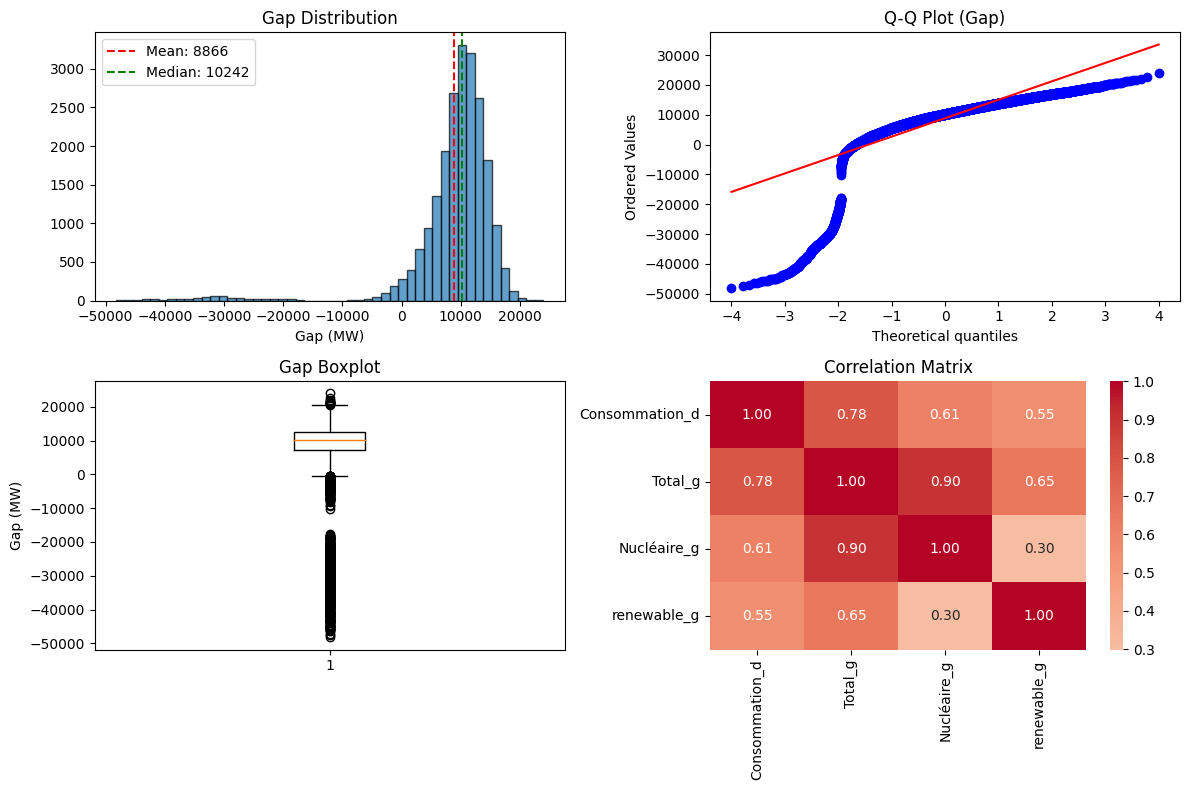


Skewness: -3.865
Kurtosis: 19.114


In [97]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['Gap'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Gap Distribution')
axes[0, 0].set_xlabel('Gap (MW)')
axes[0, 0].axvline(df['Gap'].mean(), color='red', linestyle='--', label=f"Mean: {df['Gap'].mean():.0f}")
axes[0, 0].axvline(df['Gap'].median(), color='green', linestyle='--', label=f"Median: {df['Gap'].median():.0f}")
axes[0, 0].legend()

stats.probplot(df['Gap'].dropna(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Gap)')

axes[1, 0].boxplot([df['Gap'].dropna()])
axes[1, 0].set_title('Gap Boxplot')
axes[1, 0].set_ylabel('Gap (MW)')

sample_cols = ['Consommation_d', 'Total_g', 'Nucléaire_g', 'renewable_g']
df_sample = df[sample_cols].sample(min(5000, len(df)))
sns.heatmap(df_sample.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSkewness: {df['Gap'].skew():.3f}")
print(f"Kurtosis: {df['Gap'].kurtosis():.3f}")

### Target Distribution by Time

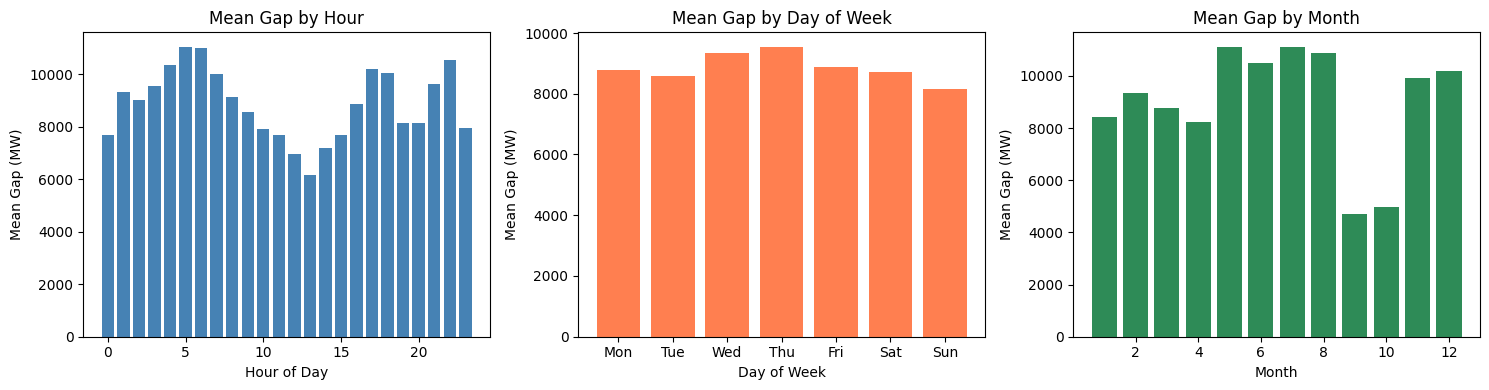

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hourly_gap = df.groupby('hour')['Gap'].mean()
axes[0].bar(hourly_gap.index, hourly_gap.values, color='steelblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Gap (MW)')
axes[0].set_title('Mean Gap by Hour')
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)

dow_gap = df.groupby('dow')['Gap'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(dow_labels, dow_gap.values, color='coral')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Gap (MW)')
axes[1].set_title('Mean Gap by Day of Week')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)

monthly_gap = df.groupby('month')['Gap'].mean()
axes[2].bar(monthly_gap.index, monthly_gap.values, color='seagreen')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Gap (MW)')
axes[2].set_title('Mean Gap by Month')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gap_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Generation Mix Analysis

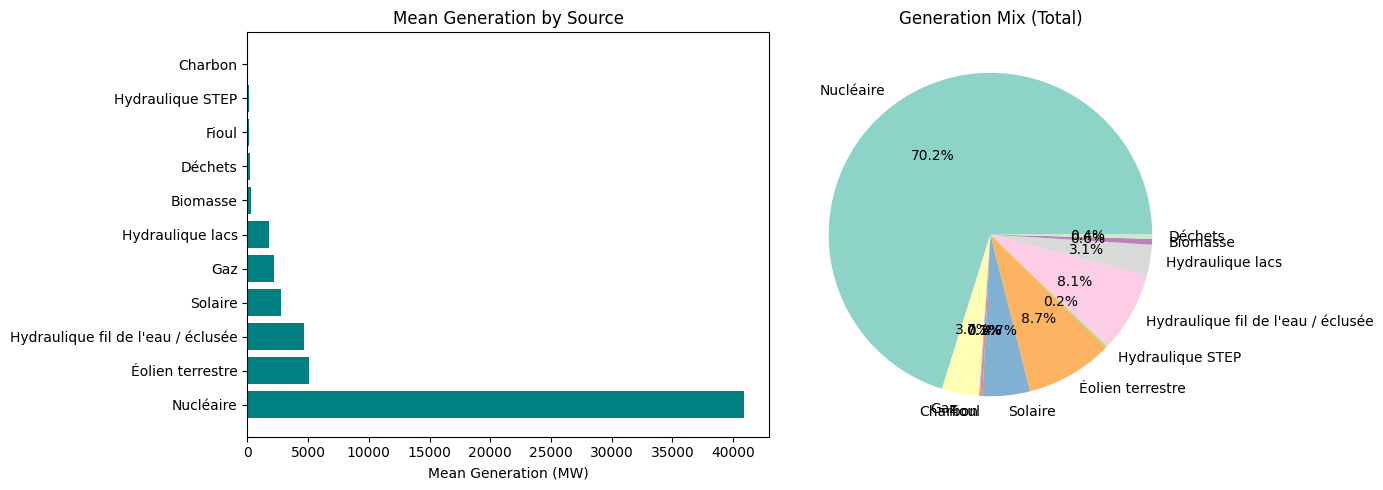

In [99]:
gen_cols = ['Nucléaire_g', 'Gaz_g', 'Charbon_g', 'Fioul_g', 'Solaire_g', 'Éolien terrestre_g', 
            'Hydraulique STEP_g', 'Hydraulique fil de l\'eau / éclusée_g', 'Hydraulique lacs_g', 
            'Biomasse_g', 'Déchets_g']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gen_means = df[gen_cols].mean().sort_values(ascending=False)
axes[0].barh(range(len(gen_means)), gen_means.values, color='teal')
axes[0].set_yticks(range(len(gen_means)))
axes[0].set_yticklabels([c.replace('_g', '') for c in gen_means.index])
axes[0].set_xlabel('Mean Generation (MW)')
axes[0].set_title('Mean Generation by Source')

gen_totals = df[gen_cols].sum()
colors = plt.cm.Set3(range(len(gen_totals)))
axes[1].pie(gen_totals, labels=[c.replace('_g', '') for c in gen_totals.index], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Generation Mix (Total)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'generation_mix.png', dpi=150, bbox_inches='tight')
plt.show()

### Demand Analysis

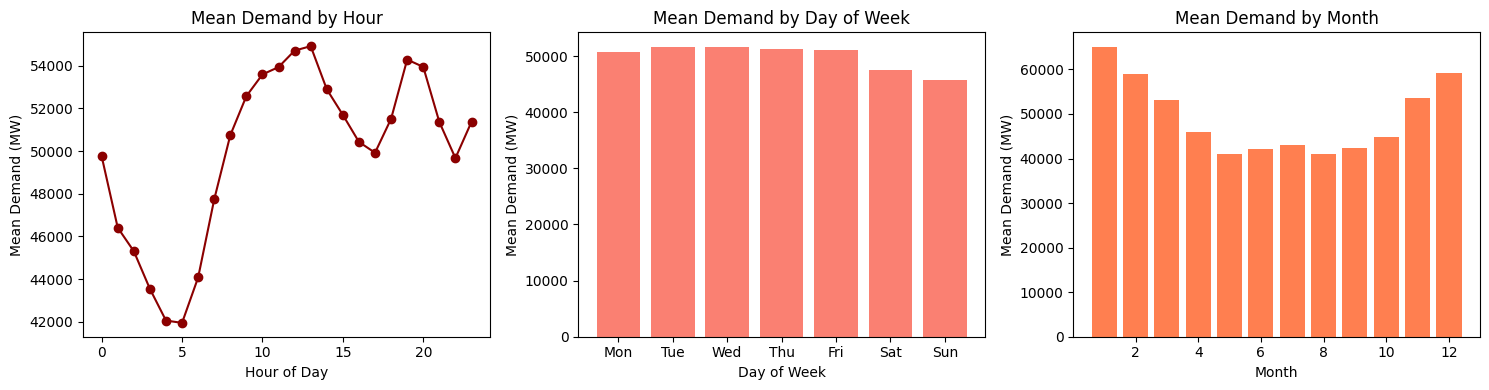

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hourly_demand = df.groupby('hour')['Consommation_d'].mean()
axes[0].plot(hourly_demand.index, hourly_demand.values, marker='o', color='darkred')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Demand (MW)')
axes[0].set_title('Mean Demand by Hour')

dow_demand = df.groupby('dow')['Consommation_d'].mean()
axes[1].bar(dow_labels, dow_demand.values, color='salmon')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Demand (MW)')
axes[1].set_title('Mean Demand by Day of Week')

monthly_demand = df.groupby('month')['Consommation_d'].mean()
axes[2].bar(monthly_demand.index, monthly_demand.values, color='coral')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Demand (MW)')
axes[2].set_title('Mean Demand by Month')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'demand_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [101]:
print("EDA completed!")

EDA completed!


## 5. Model Training

In [102]:
df.dropna(inplace=True)

target_cols = [f'Gap_t_plus_{h}h' for h in range(1, 13)]
feature_cols = [c for c in df.columns if c not in target_cols + ['Gap'] and not c.startswith('Gap_t_plus')]

print(f"Features: {len(feature_cols)}")
print(f"Targets: {len(target_cols)}")

Features: 60
Targets: 12


In [103]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

RESEARCH = True
if RESEARCH:
    TEST_SIZE = 30 * 24 
    tscv = TimeSeriesSplit(n_splits=5, test_size=TEST_SIZE)

    # base = HistGradientBoostingRegressor(
    #     learning_rate=0.05,
    #     max_depth=8,
    #     max_iter=500,
    #     random_state=42
    # )

    base = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )

    model = MultiOutputRegressor(base)

    X = df[feature_cols]
    Y = df[target_cols]

    rows = []
    all_predictions = {}
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        print(f"Fold {fold}: Train indices {train_idx[0]}-{train_idx[-1]}, Test indices {test_idx[0]}-{test_idx[-1]}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test) 

        # Evaluate each horizon separately
        for j, h in enumerate(target_cols):
            y_true_h = Y_test.iloc[:, j].values
            y_pred_h = Y_pred[:, j]
            
            if fold == 5:
                all_predictions[h] = pd.DataFrame({
                    "datetime": Y_test.index,
                    "actual": y_true_h,
                    "predicted": y_pred_h
                })

            rows.append({
                "fold": fold,
                "horizon_h": h,
                "MAE": mean_absolute_error(y_true_h, y_pred_h),
                "RMSE": rmse(y_true_h, y_pred_h),
                "R2": r2_score(y_true_h, y_pred_h)
            })

    results = pd.DataFrame(rows)

    print("Per-horizon mean across folds:")
    display(
        results.groupby("horizon_h")[["MAE","RMSE","R2"]].mean()
        .style
        .background_gradient(subset=["MAE","RMSE"], cmap="Reds_r", axis=0)
        .background_gradient(subset=["R2"], cmap="Greens", axis=0)    
    )

    print("\nOverall mean (all horizons & folds):")
    print(results[["MAE","RMSE","R2"]].mean())

Fold 1: Train indices 0-18001, Test indices 18002-18721
Fold 2: Train indices 0-18721, Test indices 18722-19441
Fold 3: Train indices 0-19441, Test indices 19442-20161
Fold 4: Train indices 0-20161, Test indices 20162-20881
Fold 5: Train indices 0-20881, Test indices 20882-21601
Per-horizon mean across folds:


,MAE,RMSE,R2
horizon_h,,,
Gap_t_plus_10h,2451.834459,3115.929380,0.112607
Gap_t_plus_11h,2346.055470,3046.442093,0.165004
Gap_t_plus_12h,2409.780251,3075.514832,0.131180
Gap_t_plus_1h,811.069743,1097.037673,0.883124
Gap_t_plus_2h,1246.142474,1643.541742,0.746024
Gap_t_plus_3h,1596.875586,2107.777331,0.600238
Gap_t_plus_4h,1793.933146,2344.106088,0.501833
Gap_t_plus_5h,1943.087139,2533.841203,0.417516
Gap_t_plus_6h,2045.537266,2613.593357,0.382909



Overall mean (all horizons & folds):
MAE     1959.529226
RMSE    2532.856160
R2         0.380527
dtype: float64


In [104]:
results_df = pd.DataFrame(results)
print("\nModel Performance Summary:")
print(results_df.to_string(index=False))


Model Performance Summary:
 fold      horizon_h         MAE        RMSE        R2
    1  Gap_t_plus_1h  728.944661  989.359990  0.887432
    1  Gap_t_plus_2h 1061.544611 1393.370113  0.775435
    1  Gap_t_plus_3h 1205.326199 1622.639839  0.694490
    1  Gap_t_plus_4h 1349.168125 1855.716829  0.599097
    1  Gap_t_plus_5h 1360.762140 1842.462014  0.603201
    1  Gap_t_plus_6h 1429.614383 1922.380574  0.565867
    1  Gap_t_plus_7h 1499.652847 1959.614396  0.546627
    1  Gap_t_plus_8h 1494.731404 1952.000296  0.547859
    1  Gap_t_plus_9h 1487.296344 1940.825141  0.547707
    1 Gap_t_plus_10h 1561.036654 2029.447877  0.499598
    1 Gap_t_plus_11h 1452.979545 1910.163264  0.547433
    1 Gap_t_plus_12h 1451.735045 1936.132243  0.520430
    2  Gap_t_plus_1h  880.900454 1155.601412  0.846217
    2  Gap_t_plus_2h 1356.989526 1774.386903  0.638392
    2  Gap_t_plus_3h 1715.684603 2200.285810  0.443259
    2  Gap_t_plus_4h 2079.096734 2580.169837  0.233778
    2  Gap_t_plus_5h 2103.140416 2577

## 6. Prediction Distribution Analysis

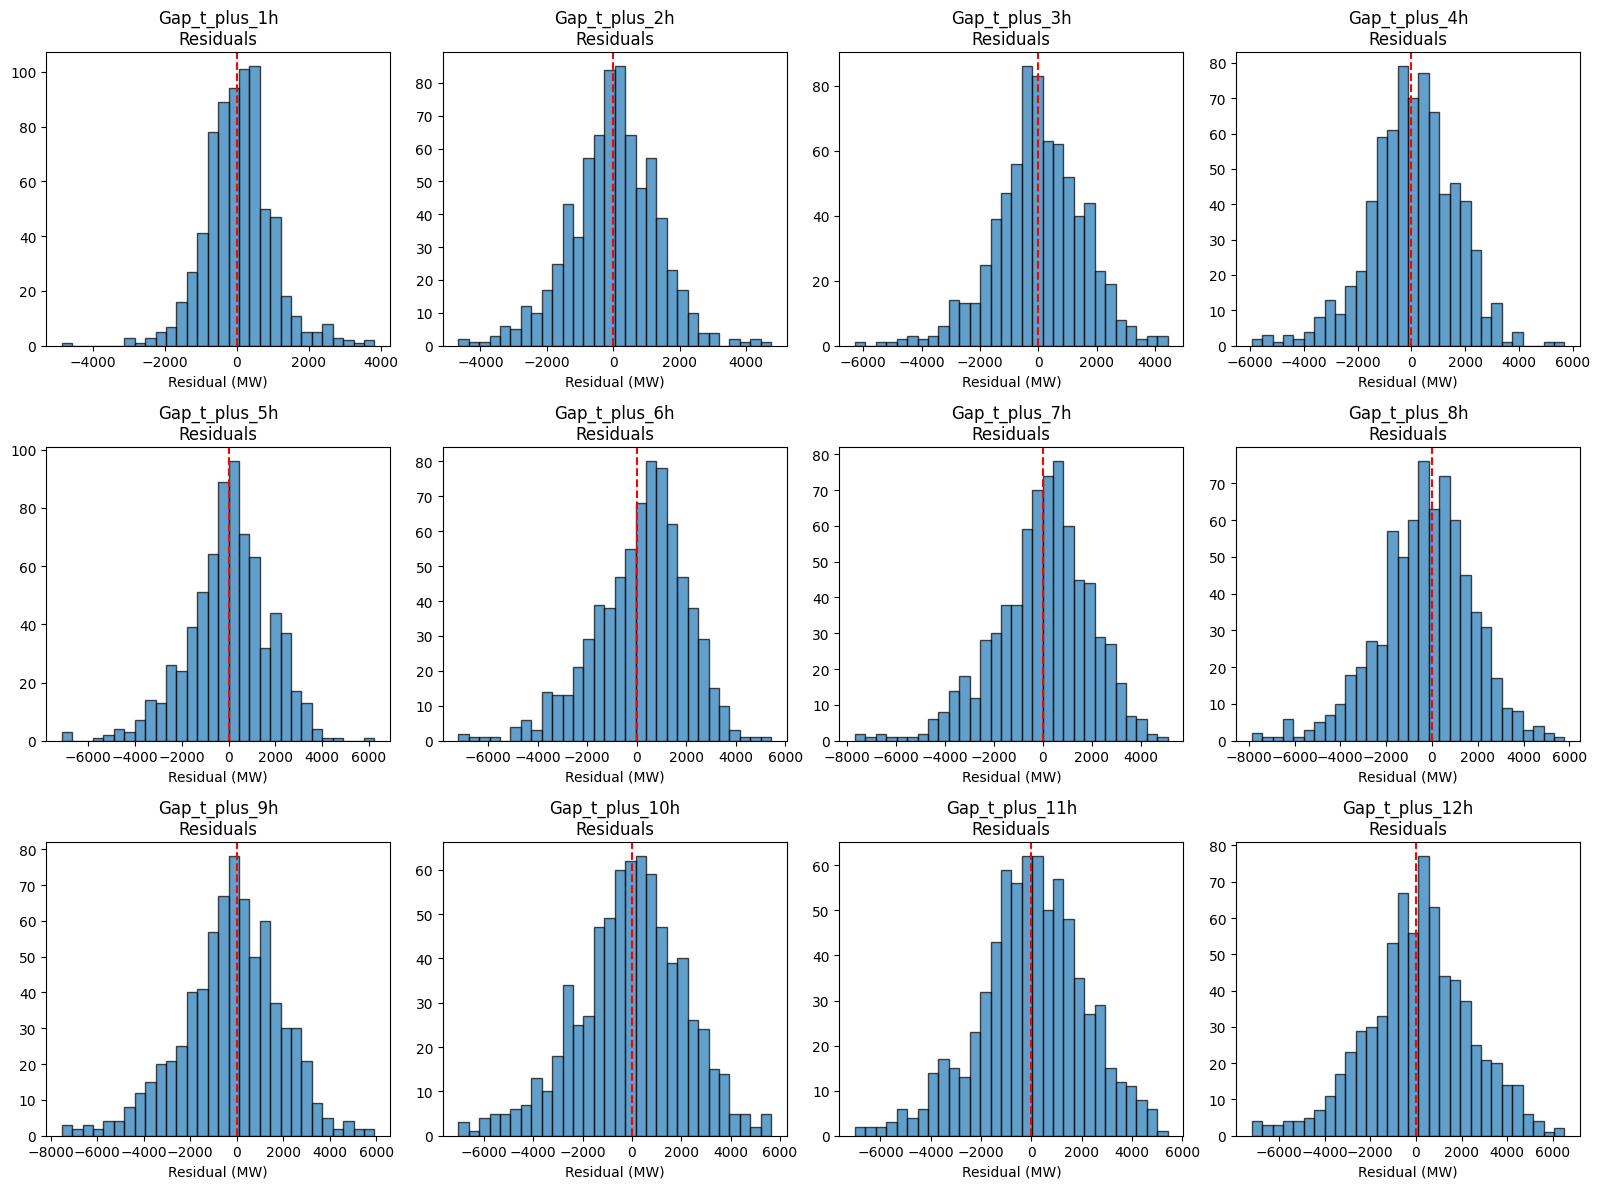

In [105]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    residuals = pred_df['actual'] - pred_df['predicted']
    
    axes[idx].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{target}\nResiduals')
    axes[idx].set_xlabel('Residual (MW)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

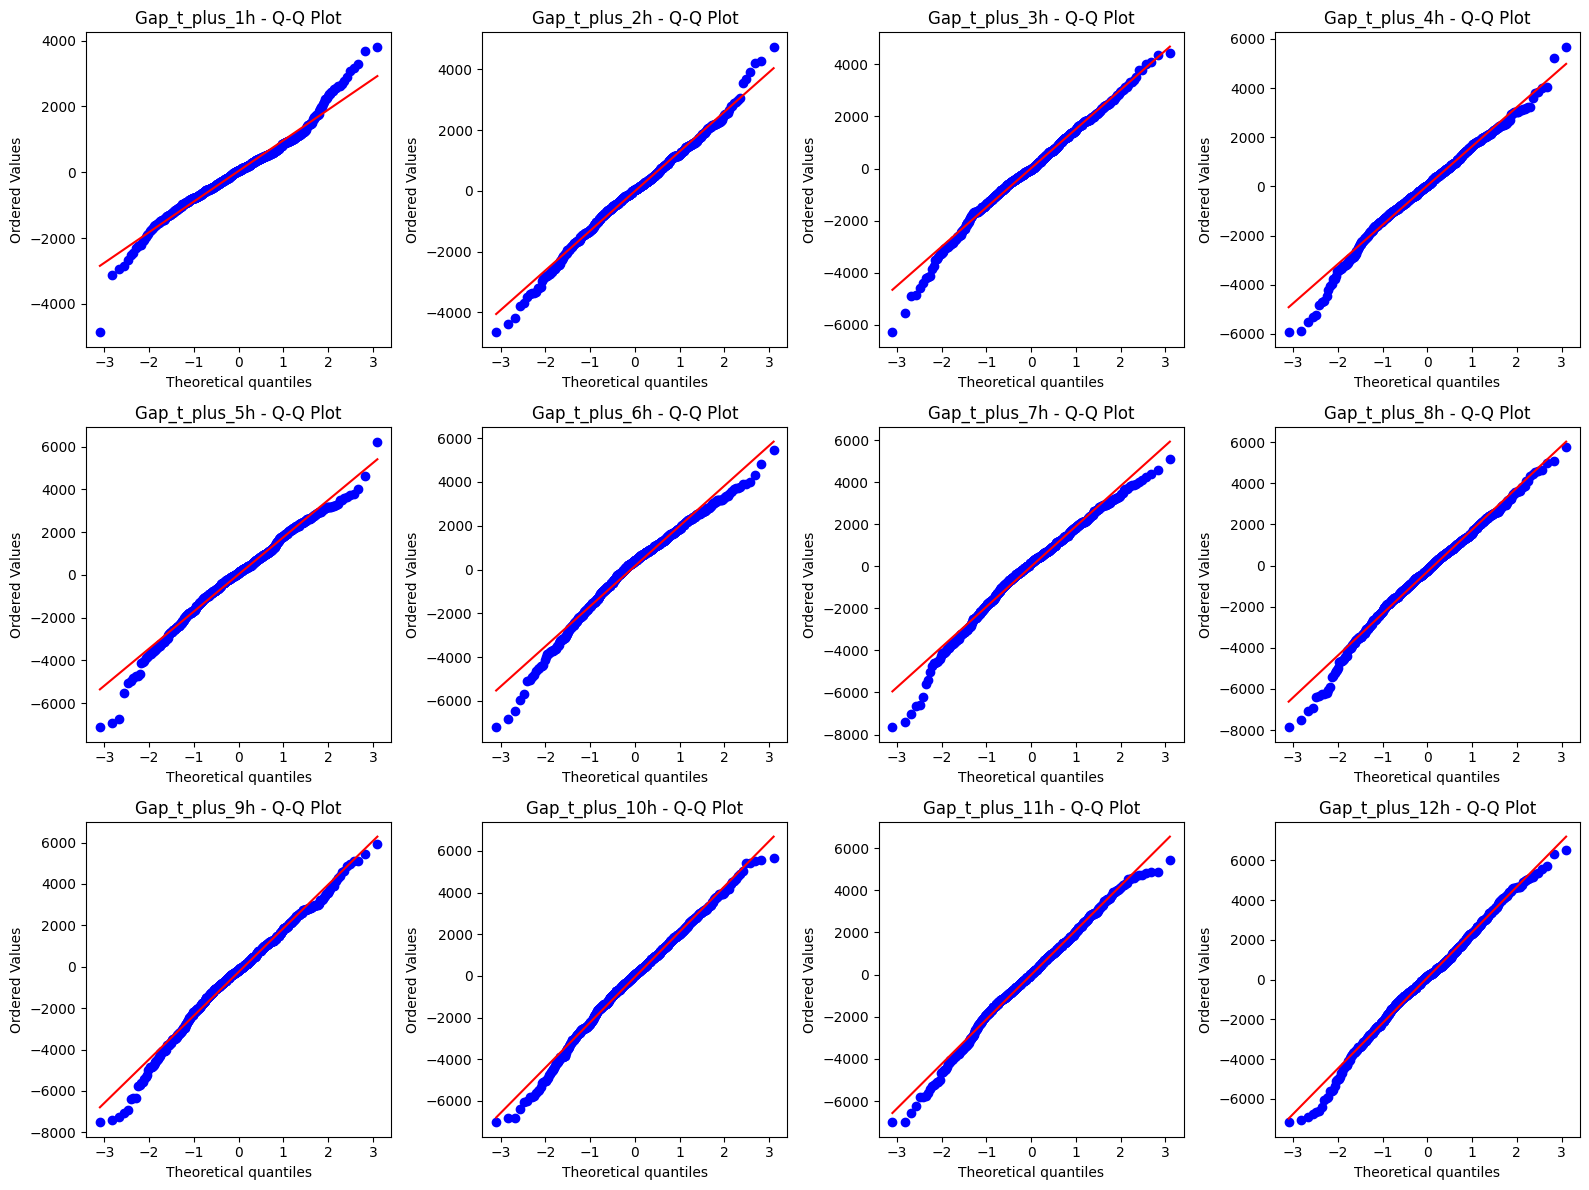

In [106]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    
    stats.probplot(pred_df['actual'] - pred_df['predicted'], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'{target} - Q-Q Plot')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'qq_plots_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

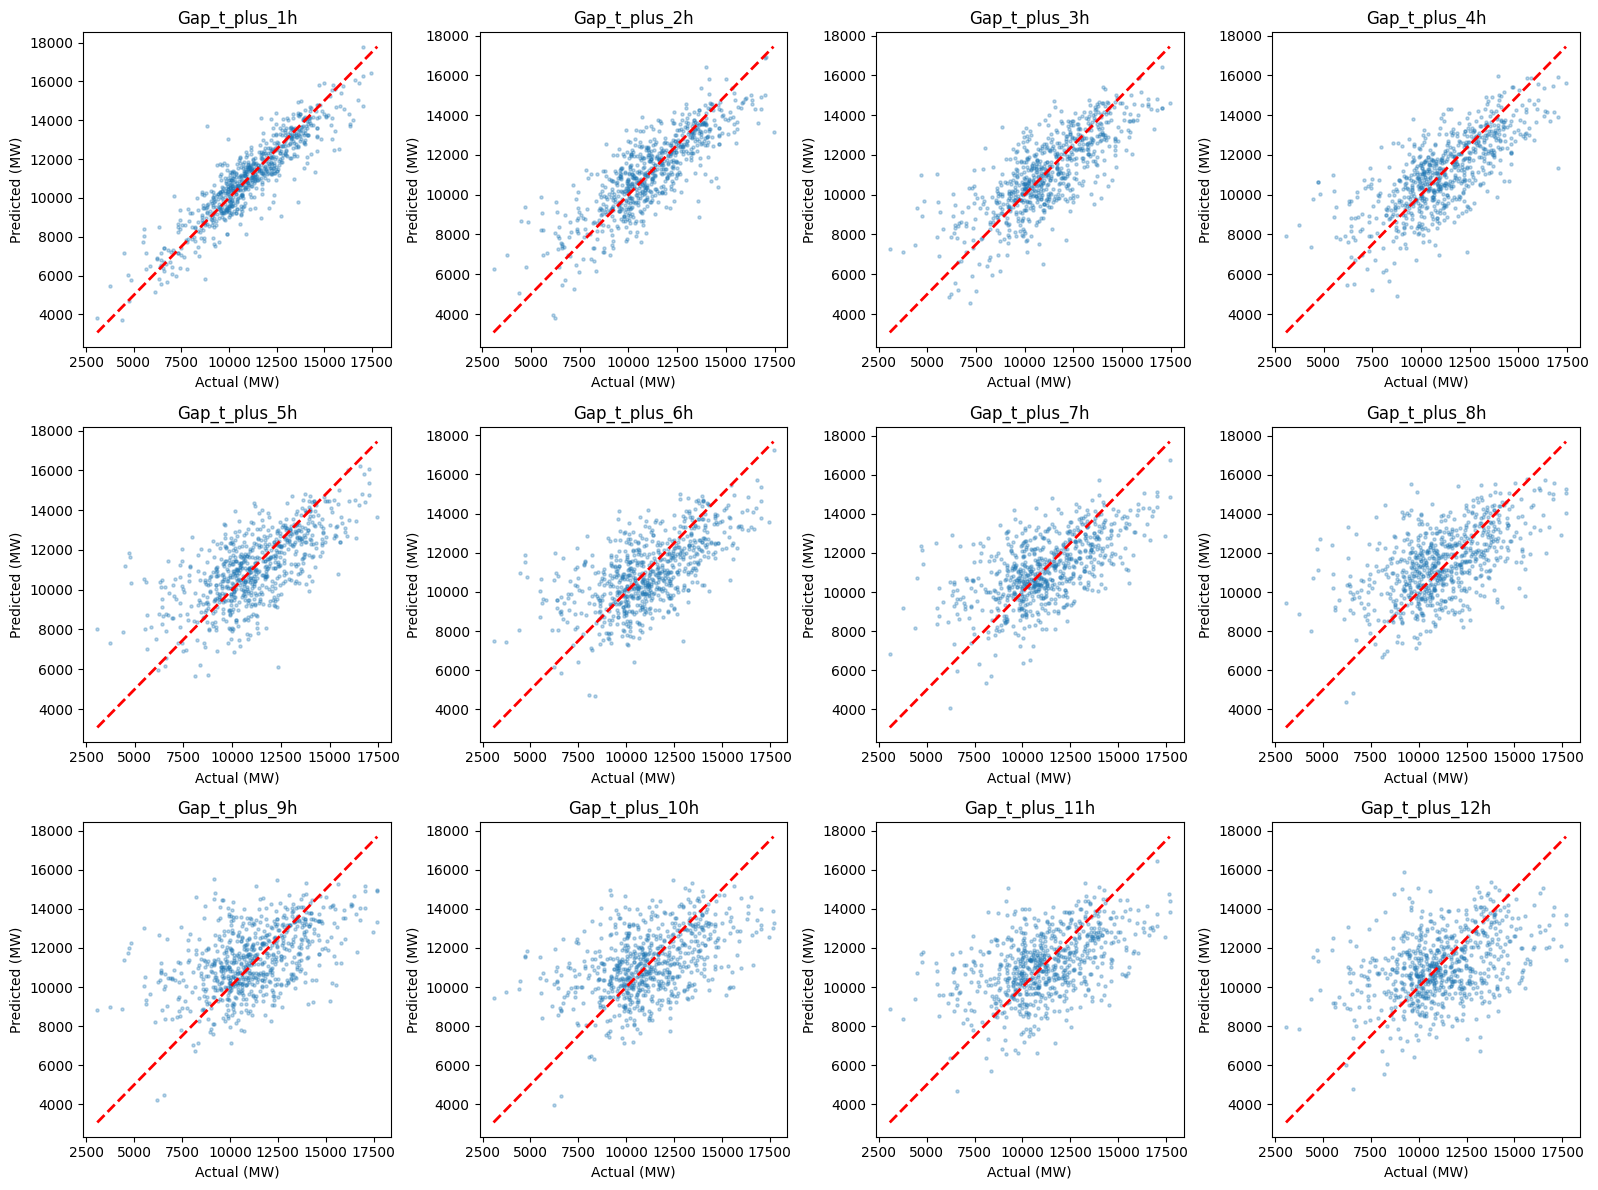

In [107]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    
    axes[idx].scatter(pred_df['actual'], pred_df['predicted'], alpha=0.3, s=5)
    min_val = min(pred_df['actual'].min(), pred_df['predicted'].min())
    max_val = max(pred_df['actual'].max(), pred_df['predicted'].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[idx].set_xlabel('Actual (MW)')
    axes[idx].set_ylabel('Predicted (MW)')
    axes[idx].set_title(f'{target}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Inference

In [111]:
# Split last 7 days as final test set (unseen during training)
date_range = pd.date_range('2026-02-08', '2026-02-16', freq='H')
test_set = df[df.index.isin(date_range)]

train_set = df[~df.index.isin(date_range)]
train_set.to_parquet("fr_train_set.parquet", index=True)

test_set[feature_cols].to_parquet("fr_x_test_set.parquet", index=True)
test_set[target_cols].to_parquet("fr_y_test_set.parquet", index=True)

# Fit xgboost on train set
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)
X_train = train_set[feature_cols]
Y_train = train_set[target_cols]

model.fit(X_train, Y_train)

joblib.dump(model, "fr_model.joblib")


# Predict on test set
X_test = test_set[feature_cols]
Y_test = test_set[target_cols]
Y_pred = model.predict(X_test)

# Evaluate
test_results = []
for j, h in enumerate(target_cols):
    y_true_h = Y_test.iloc[:, j].values
    y_pred_h = Y_pred[:, j]

    test_results.append({
        "horizon_h": h,
        "MAE": mean_absolute_error(y_true_h, y_pred_h),
        "RMSE": rmse(y_true_h, y_pred_h),
        "R2": r2_score(y_true_h, y_pred_h)
    })
test_results_df = pd.DataFrame(test_results)
display(
    test_results_df
    .style
    .background_gradient(subset=["MAE","RMSE"], cmap="Reds_r", axis=0)
    .background_gradient(subset=["R2"], cmap="Greens", axis=0)
)

,horizon_h,MAE,RMSE,R2
0,Gap_t_plus_1h,788.064557,1065.929206,0.777360
1,Gap_t_plus_2h,1069.156458,1413.054357,0.611112
2,Gap_t_plus_3h,1220.380897,1622.069179,0.488526
3,Gap_t_plus_4h,1305.326537,1724.001849,0.421700
4,Gap_t_plus_5h,1377.115349,1779.829746,0.391418
5,Gap_t_plus_6h,1495.692183,1908.563595,0.315317
6,Gap_t_plus_7h,1569.827858,2064.621274,0.207055
7,Gap_t_plus_8h,1641.521973,2180.363955,0.114989
8,Gap_t_plus_9h,1625.955260,2128.548060,0.154603
9,Gap_t_plus_10h,1712.469663,2182.232155,0.111417


## 8. Exports

In [112]:
results_df.to_csv(OUTPUT_DIR / 'metrics.csv', index=False)
print(f"Exported: {OUTPUT_DIR / 'metrics.csv'}")

predictions_combined = pd.concat(all_predictions, names=['horizon']).reset_index()
predictions_combined.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
print(f"Exported: {OUTPUT_DIR / 'predictions.csv'}")

Exported: /Users/armandhubler/Documents/coding_project/hackeurope26/ml/fr/metrics.csv
Exported: /Users/armandhubler/Documents/coding_project/hackeurope26/ml/fr/predictions.csv


## 9. Sample Day Visualization

In [117]:
day_data.columns

Index(['PrévisionJ-1_d', 'PrévisionJ_d', 'Consommation_d', 'Biomasse_g',
       'Gaz_g', 'Charbon_g', 'Fioul_g', 'Hydraulique STEP_g',
       'Hydraulique fil de l'eau / éclusée_g', 'Hydraulique lacs_g',
       'Nucléaire_g', 'Solaire_g', 'Déchets_g', 'Éolien terrestre_g',
       'Total_g', 'Éolien en mer_g', 'Gap', 'Gap_t_plus_1h', 'Gap_t_plus_2h',
       'Gap_t_plus_3h', 'Gap_t_plus_4h', 'Gap_t_plus_5h', 'Gap_t_plus_6h',
       'Gap_t_plus_7h', 'Gap_t_plus_8h', 'Gap_t_plus_9h', 'Gap_t_plus_10h',
       'Gap_t_plus_11h', 'Gap_t_plus_12h', 'renewable_g', 'gas_generation',
       'total_fossil', 'fossil_share', 'gen_minus_load', 'imbalance_log_ratio',
       'Gap_lag_1', 'gen_minus_load_lag_1', 'imbalance_log_ratio_lag_1',
       'Gap_lag_2', 'gen_minus_load_lag_2', 'imbalance_log_ratio_lag_2',
       'Gap_lag_3', 'gen_minus_load_lag_3', 'imbalance_log_ratio_lag_3',
       'Gap_lag_6', 'gen_minus_load_lag_6', 'imbalance_log_ratio_lag_6',
       'Gap_lag_12', 'gen_minus_load_lag_12', 'im

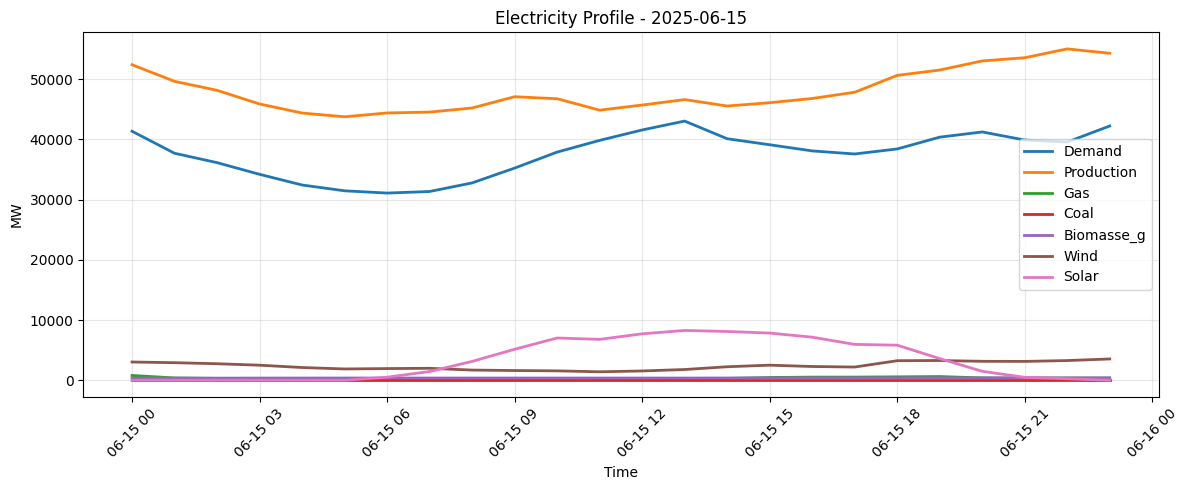

In [119]:
sample_date = '2025-06-15'
day_data = df[df.index.date == pd.to_datetime(sample_date).date()]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(day_data.index, day_data['Consommation_d'], label='Demand', linewidth=2)
ax.plot(day_data.index, day_data['Total_g'], label='Production', linewidth=2)
ax.plot(day_data.index, day_data['Gaz_g'], label='Gas', linewidth=2)
ax.plot(day_data.index, day_data['Charbon_g'], label='Coal', linewidth=2)
ax.plot(day_data.index, day_data['Biomasse_g'], label='Biomasse_g', linewidth=2)
ax.plot(day_data.index, day_data['Éolien terrestre_g'], label='Wind', linewidth=2)
ax.plot(day_data.index, day_data['Solaire_g'], label='Solar', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('MW')
ax.set_title(f'Electricity Profile - {sample_date}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [120]:
print("="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Dataset: Finland Electricity")
print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")
print(f"Target: Gap (production - demand)")
print(f"Horizons: 1-12 hours")
print(f"\nTarget statistics:")
print(f"  Mean Gap: {df['Gap'].mean():.2f} MW")
print(f"  Std Gap: {df['Gap'].std():.2f} MW")
print(f"  Min Gap: {df['Gap'].min():.2f} MW")
print(f"  Max Gap: {df['Gap'].max():.2f} MW")
print(f"\nInterpretation:")
print(f"  Negative gap = demand exceeds production (importing)")
print(f"  Positive gap = production exceeds demand (exporting)")

MODEL SUMMARY
Dataset: Finland Electricity
Total samples: 21602
Features: 60
Target: Gap (production - demand)
Horizons: 1-12 hours

Target statistics:
  Mean Gap: 8862.52 MW
  Std Gap: 7773.91 MW
  Min Gap: -48213.00 MW
  Max Gap: 23931.00 MW

Interpretation:
  Negative gap = demand exceeds production (importing)
  Positive gap = production exceeds demand (exporting)
